### Power spectra of reconstructed T-S profiles compared to EM-APEX obs

In [1]:
import os
import matplotlib.pyplot as plt 
import numpy as np
import zarr
import xarray as xr
from xgcm import Grid
import cmocean
import warnings
from datetime import datetime, timedelta
import matplotlib as mpl
import gsw
import scipy
import matplotlib.ticker as mticker
import matplotlib

In [2]:
workingdir = '/g/data/jk72/mj0995'
os.chdir(workingdir) 

import functions as func

/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.01/lib/python3.10/site-packages/pyproj/__init__.py:89: UserWarning: pyproj unable to set database path.
  _pyproj_global_context_initialize()


In [3]:
savepath = os.path.join(workingdir, 'figures')

In [4]:
%matplotlib inline
plt.rcParams['font.size'] = '12'
warnings.filterwarnings("ignore", category=RuntimeWarning)

In [5]:
satgem_sel = xr.open_dataset('data/satgem_SEIR_on_d_noisy.nc')

In [6]:
## load particle file
lon0 = 153
y = np.arange(-58, -50.95, 0.1)
x = np.tile(lon0, y.shape)
t = '2018-11-20'
n_days = 15
pc = 5 # percent noise in velocities

filename = f'output/SEIR/MeridionalSection_{lon0}_{n_days}days_{pc}noise_{t}.zarr'
# filename = f'output/SEIR/MeridionalSection_{lon0}_{n_days}days_{pc}noise_smooth_perturb_{t}.zarr'

ds_out = xr.open_zarr(filename)
df = ds_out.to_dataframe()

In [7]:
days = 10
timestep = 6 #hours
sample_interval = int(24/timestep)
t_ind = days*sample_interval

In [8]:
t0 = np.where(satgem_sel.time == satgem_sel.time.sel(time = t, method = 'nearest'))[0][0]

start = satgem_sel.time[t0-days].data
end = satgem_sel.time[t0].data
print(start, end)

2018-11-10T00:00:00.000000000 2018-11-20T00:00:00.000000000


In [9]:
dens = np.arange(27.1, 27.5, 0.01)
col_idx = np.arange(0, len(ds_out.trajectory), len(dens))

originT, originS = func.origin_TS(ds_out, col_idx, t_ind, dens)

In [10]:
seed_temp = ds_out.temp[:, 0]
seed_sal = ds_out.sal[:, 0]

ti, si, dens_contour = func.tsDensContour(seed_sal, seed_temp)

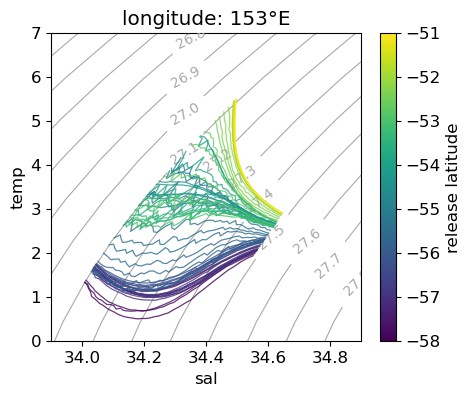

In [11]:
fig, ax = plt.subplots(figsize = (5, 4))

CS = ax.contour(si, ti, dens_contour, levels = np.arange(26.4, 27.9, 0.1), linewidths = 0.8, colors='darkgrey')
plt.clabel(CS, inline=1, fontsize=10, fmt = '%1.1f')

n = len(y)
colors = plt.cm.viridis(np.linspace(0,1,n))

k = 0
for prof in range(len(originS)): 
    im = ax.plot(originS[prof], originT[prof], c= colors[k], linewidth = 0.9, alpha = 0.8, zorder= 20)
    k+=1


plt.xlim(33.9,34.9)
plt.ylim(0, 7)
plt.ylabel('temp')
plt.xlabel('sal')

sm = plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(vmin=min(y), vmax=max(y)))
plt.colorbar(sm, ax=ax, label = 'release latitude')

plt.title(f'{pc}% noise, $-${days} days')
plt.title(f'longitude: {lon0}°E')
plt.show()

In [12]:
xx = np.repeat(x[:, np.newaxis], len(dens), axis=1)
dens_2d = np.repeat(dens[np.newaxis, :], xx.shape[0], axis=0)

dsc = func.DSC(originT, originS, dens_2d, vert_smooth = False, x_smooth = False)
dsc['latitude'] = y

In [13]:
mean_dsc = abs(dsc).mean(dim ='potential_density')

Text(0.5, 1.0, '153°E, time: 2018-11-10$-$2018-11-20')

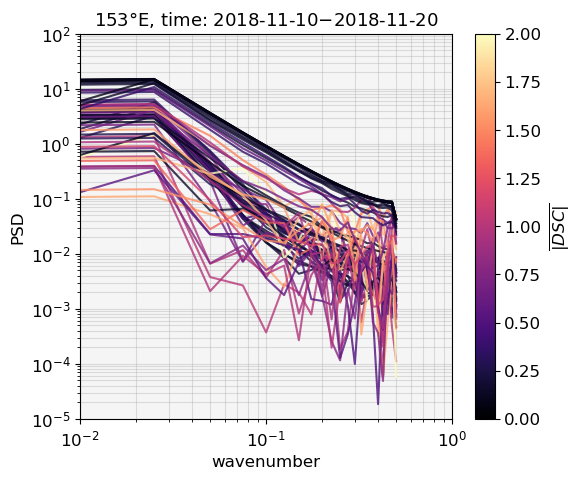

In [14]:
values = mean_dsc
norm = matplotlib.colors.Normalize(vmin=0, vmax=2)
cmap = plt.cm.magma

fig, ax = plt.subplots(figsize = (6,5))

k = 0
S_tot = {}
for prof in range(len(originS)): 
    (f, S) = scipy.signal.periodogram(originT[prof], scaling='density')
    S_tot[prof] = S
    plt.plot(f, S, color=cmap(norm(values[k])), alpha = 0.8)
    k+=1
    
plt.xscale('log')
plt.yscale('log')

ax.set_xlim(10**-2, 1)
ax.set_ylim(10**-5, 10**2)

ax.set_facecolor('whitesmoke')
plt.grid(which="both", alpha = 0.4)

plt.xlabel('wavenumber')
plt.ylabel('PSD')

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
plt.colorbar(sm, ax=ax, label = '$\overline{|DSC|}$')
st, en = start.astype('M8[D]'), end.astype('M8[D]')
plt.title(f'{lon0}°E, time: {st}$-${en}', fontsize = 13)

### all advection periods

In [15]:
originT_ds = {}
originS_ds = {}

for t in ['2018-10-31', '2018-11-20', '2018-12-01']:
    
    filename = f'output/SEIR/MeridionalSection_{lon0}_{n_days}days_{pc}noise_{t}.zarr'

    ds_out = xr.open_zarr(filename)
    
    col_idx = np.arange(0, len(ds_out.trajectory), len(dens))

    originT, originS = func.origin_TS(ds_out, col_idx, t_ind, dens)
    originT['time'] = t
    originS['time'] = t
    
    
    originT_ds[t] = originT
    originS_ds[t] = originS

In [16]:
data_list = list(originT_ds.values())
concat_T = xr.concat(data_list, dim = 'latitude')

data_list = list(originS_ds.values())
concat_S = xr.concat(data_list, dim = 'latitude')

In [17]:
dens_2d = np.repeat(dens[np.newaxis, :],len(concat_T), axis=0)

In [18]:
# Tsmooth = concat_T.rolling(potential_density =3, center = True, min_periods = 1).mean()

In [19]:
dsc = func.DSC(concat_T, concat_S, dens_2d, vert_smooth = False, x_smooth = False)

In [20]:
mean_dsc = abs(dsc).mean(dim ='potential_density')

In [21]:
# prof = 42
# print(f'mean dsc: {mean_dsc[prof]:.2f}')

# fig, (ax1, ax2) = plt.subplots(1, 2, sharey = True, figsize = (6, 6))
# concat_T[prof].plot(ax = ax1, y = 'potential_density')
# ax1.set_title('')

# concat_S[prof].plot(ax = ax2, y = 'potential_density')
# ax2.set_title('')

# fig.suptitle(f'latitude: {concat_T[prof].latitude.data:.1f}, time: {concat_T[prof].time.data}', y = 0.93)

In [22]:
new_da = xr.DataArray(concat_T.data, dims = ['dsc', 'potential_density'], 
             coords = dict(dsc = ('dsc', mean_dsc.data), 
                          potential_density = ('potential_density', dsc.potential_density.data)))

T_sort = new_da.sortby('dsc')

Text(0.5, 1.0, 'particles 153°E, profiles = 213')

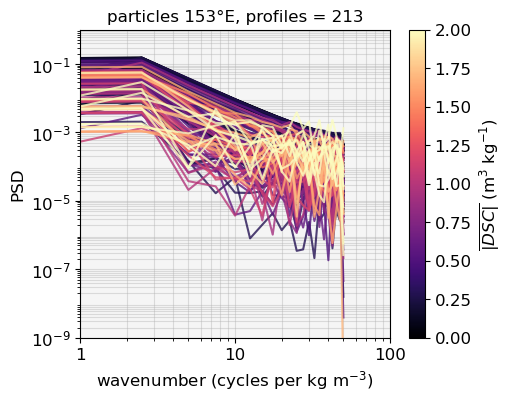

In [27]:
nonans = np.where(~np.isnan(T_sort.dsc))[0]

values = T_sort.dsc[nonans]
norm = matplotlib.colors.Normalize(vmin=0, vmax=2)
cmap = plt.cm.magma

dz = 0.01
fs = 1/dz

fig, ax = plt.subplots(figsize = (5, 4))

k = 0

S_tot = {}
for prof in range(len(T_sort[nonans])): 
    T = T_sort[nonans][prof]
    (f, S) = scipy.signal.periodogram(T, fs = fs, scaling='density')
    S_tot[prof] = S
    plt.plot(f, S, color=cmap(norm(values[k])), alpha = 0.8)
    k+=1
    
plt.xscale('log')
plt.yscale('log')

ax.set_xlim(10**0, 10**2)
ax.set_ylim(10**-9, 10**0)

ax.set_yticks([10**-1, 10**-3, 10**-5, 10**-7, 10**-9])
ax.set_xticks([10**0, 10**1, 10**2], [1, 10, 100])

ax.set_facecolor('whitesmoke')

plt.grid(which="both", alpha = 0.4)

plt.xlabel('wavenumber (cycles per kg m$^{-3}$)')
plt.ylabel('PSD')

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
plt.colorbar(sm, ax=ax, label = '$\overline{|DSC|}$ (m$^{3}$ kg$^{-1}$)')
plt.title(f'particles {lon0}°E, profiles = {len(concat_T)}', fontsize = 12)

In [28]:
# name = f'power_spectra_reconstructed_TS.png'
# fig.savefig(os.path.join(savepath, name), dpi = 300, bbox_inches='tight', pad_inches= 0.2)

In [29]:
spectra = np.vstack(S_tot.values())
psd = xr.DataArray(spectra, dims = ['dsc', 'PSD'], coords = dict(dsc = ('dsc', T_sort.dsc[nonans].data)))

/jobfs/128584472.gadi-pbs/ipykernel_2309313/1348552845.py:1: FutureWarning: arrays to stack must be passed as a "sequence" type such as list or tuple. Support for non-sequence iterables such as generators is deprecated as of NumPy 1.16 and will raise an error in the future.
  spectra = np.vstack(S_tot.values())


In [30]:
low_dsc = np.where((psd.dsc < 1.25) & (psd.dsc > 0.5))[0]
# low_dsc = np.where((psd.dsc < 1.25))[0]
high_dsc = np.where(psd.dsc >= 1.25)[0]

In [31]:
len(low_dsc)

48

In [32]:
len(high_dsc)

25

In [33]:
# four floats
low_dsc_flt = [1.90298498e-32, 2.71176884e-02, 6.05259650e-03, 2.13148947e-03,
       1.30920816e-03, 6.34717202e-04, 4.77324865e-04, 3.68090426e-04,
       2.84068413e-04, 2.27631345e-04, 1.78747135e-04, 1.55328440e-04,
       1.43406992e-04, 1.22371233e-04, 1.03120858e-04, 9.62941307e-05,
       8.88096818e-05, 8.68309483e-05, 8.24751901e-05, 8.17450541e-05,
       4.27802002e-05]

high_dsc_flt = [1.98685588e-32, 2.58845450e-02, 9.14052404e-03, 4.61143611e-03,
       2.53723002e-03, 1.22114361e-03, 1.07493836e-03, 6.68615237e-04,
       6.85485767e-04, 4.51976929e-04, 3.44824125e-04, 2.73819021e-04,
       2.73316930e-04, 2.43821680e-04, 1.87421285e-04, 1.64384954e-04,
       1.58500347e-04, 1.65145376e-04, 1.56842392e-04, 1.65981123e-04,
       7.06259108e-05]

In [34]:
n_lines = 6
cmap = mpl.colormaps['plasma']

# Take colors at regular intervals spanning the colormap.
colors = cmap(np.linspace(0, 1, n_lines))

Text(0, 0.5, 'PSD')

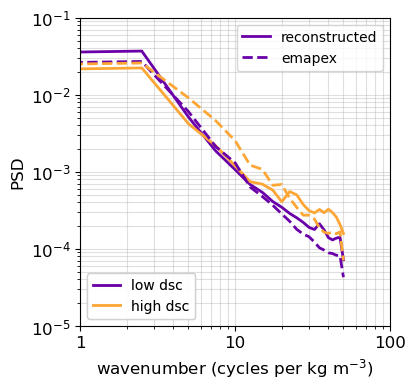

In [43]:
fig, ax = plt.subplots(figsize = (4,4))

# for i in range(len(psd[low_dsc])):
#     plt.plot(f, psd[low_dsc][i], c = 'tab:blue', alpha = 0.2)
    
plt.plot(f, psd[low_dsc].mean(dim = 'dsc'), c = colors[1], linewidth = 2)
plt.plot(f, psd[high_dsc].mean(dim = 'dsc'), c = colors[4], linewidth = 2)

# for i in range(len(psd[high_dsc])):
#     plt.plot(f, psd[high_dsc][i], c = 'tab:red', alpha = 0.2)
    
plt.plot(f, low_dsc_flt,  c = colors[1], linewidth = 2, linestyle = '--')
plt.plot(f, high_dsc_flt, c = colors[4], linewidth = 2, linestyle = '--')

lines = ax.get_lines()
legend1 = plt.legend([lines[i] for i in [0, 2]], ["reconstructed", "emapex"], loc=1, fontsize = 10)
legend2 = plt.legend([lines[i] for i in [0, 1]], ["low dsc", "high dsc"], loc=3, fontsize = 10)
ax.add_artist(legend1)
ax.add_artist(legend2)
# [legend1.set_color('darkgrey') for legend1 in legend1.legend_handles]

plt.grid(which="both", alpha = 0.4)

plt.xscale('log')
plt.yscale('log')

ax.set_xlim(10**0, 10**2)
ax.set_ylim(10**-5, 10**-1)

ax.set_xticks([10**0, 10**1, 10**2], [1, 10, 100])

plt.xlabel('wavenumber (cycles per kg m$^{-3}$)')
plt.ylabel('PSD')

In [44]:
# name = f'power_spectra_comparison.png'
# fig.savefig(os.path.join(savepath, name), dpi = 300, bbox_inches='tight', pad_inches= 0.2)